# Imports

In [1]:
import numpy as np
import tensorflow_probability as tfp
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.image as mpimg

tfd = tfp.distributions

In [2]:
global iteration_count, x_obs, y_obs, next_x_to_observe, next_y_to_observe, bo_iteration_figures

# Initialize a list to store all generated BO iteration figures
bo_iteration_figures = []

# Initialize iteration count. It will be incremented before the first plot.
iteration_count = 0

# GP prior generation

In [3]:
def squaredExponential(x, x_prime, signal_variance, length_scale):
    return signal_variance * np.exp( -( np.subtract.outer(x, x_prime)**2 / (2 * length_scale**2) ) )

In [4]:
import io
from matplotlib.backends.backend_agg import FigureCanvasAgg

def render_figure_to_image(fig):
    """Renders a matplotlib Figure to an in-memory PNG image, then closes the figure."""
    buf = io.BytesIO()
    canvas = FigureCanvasAgg(fig)
    canvas.print_png(buf)
    buf.seek(0)
    img = mpimg.imread(buf)
    plt.close(fig) # Close the original figure to free memory
    return img

def plot_bo_iteration(x, true_obj_func, x_obs, y_obs, mu_post, std_dev_post,
                      f_posterior_samples, expected_improvement,
                      next_x_to_observe, next_y_to_observe, iteration_count):
    """
    Generates a Matplotlib figure for a single Bayesian Optimization iteration.
    Returns the figure object.
    """
    fig, (ax_gp, ax_acq) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # --- GP Plot (Top Subplot) ---
    ax_gp.fill_between(
        x,
        mu_post - 1.96 * std_dev_post,
        mu_post + 1.96 * std_dev_post,
        alpha = 0.2,
        color = "grey",
        label = "95% confidence interval"
    )

    for i in range(f_posterior_samples.shape[0]):
        ax_gp.plot(x, f_posterior_samples[i], color='darkorange', linewidth=0.7)

    ax_gp.plot(x, mu_post, color='purple', linewidth=2, label='Posterior mean')
    ax_gp.plot(x, true_obj_func(x), lw=2, color="black", linestyle='--', label="Objective function")
    ax_gp.plot(x_obs, y_obs, 'o', markersize=8, color='red', label='Observed points')
    ax_gp.axvline(next_x_to_observe, color='green')
    ax_gp.plot(next_x_to_observe, next_y_to_observe, 'o', markersize=8, color='green', label='New point')

    ax_gp.set_title(f"Bayes opt iteration {iteration_count}: GP fit and objective function")
    ax_gp.set_ylim(-4, 4)
    ax_gp.legend(loc="lower right")

    # --- Acquisition Function Plot (Bottom Subplot) ---
    ax_acq.plot(x, expected_improvement, color='purple', label='Expected improvement')
    ax_acq.plot(next_x_to_observe, np.max(expected_improvement),
                'o', markersize=8, color='green')
    ax_acq.axvline(next_x_to_observe, color='green', label='Max EI ppoint')

    ax_acq.set_title(f"Bayes opt iteration {iteration_count}: Expected improvement")
    ax_acq.set_xlabel("Input, x")
    ax_acq.set_ylabel("EI value")
    ax_acq.legend(loc='lower right')

    plt.tight_layout()
    return fig

In [5]:
# assuming a much finer and longer x space
x = np.linspace(start = -6, stop = 6, num = 500)

# calculate the covariance matrix
covariance_matrix1 = squaredExponential(x, x, signal_variance=1, length_scale=1)
covariance_matrix2 = squaredExponential(x, x, signal_variance=0.3, length_scale=1)
covariance_matrix3 = squaredExponential(x, x, signal_variance=1, length_scale=0.1)

# define a multivariate normal
f1 = tfd.MultivariateNormalTriL(
    # mean vector of 0s
    loc = np.zeros(len(x)),

    # triangular matrix for Cholesky decomp
    # with jitter added for numerical stability at float64
    scale_tril=tf.linalg.cholesky(
        covariance_matrix1 + (tf.eye(len(x), dtype = tf.float64) * 1e-6)
    )
)

f2 = tfd.MultivariateNormalTriL(
    loc = np.zeros(len(x)),
    scale_tril=tf.linalg.cholesky(
        covariance_matrix2+ (tf.eye(len(x), dtype = tf.float64) * 1e-6)
    )
)

f3 = tfd.MultivariateNormalTriL(
    loc = np.zeros(len(x)),
    scale_tril=tf.linalg.cholesky(
        covariance_matrix3+ (tf.eye(len(x), dtype = tf.float64) * 1e-6)
    )
)

# draw 10 samples from it
f1 = f1.sample(10)
f2 = f2.sample(10)
f3 = f3.sample(10)

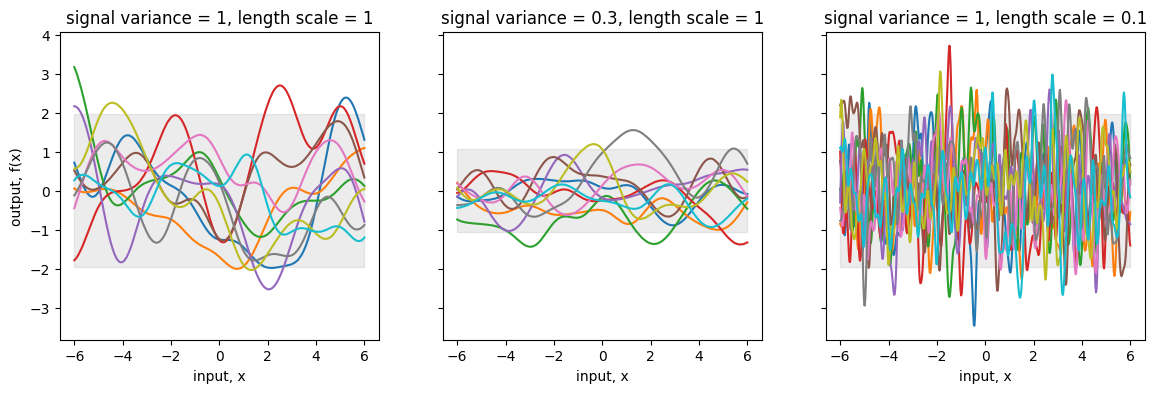

In [6]:
import numpy as np
import tensorflow_probability as tfp
import tensorflow as tf
import matplotlib.pyplot as plt

tfd = tfp.distributions

# plot them
fig, ax = plt.subplots(1, 3, figsize=(14,4), sharey=True)
for i in range(f1.shape[0]):
    ax[0].plot(x, f1[i])
    ax[1].plot(x, f2[i])
    ax[2].plot(x, f3[i])

# error bands are generated using the signal variance
# bands are 2 standard deviations * sqrt(signal variance)
ax[0].fill_between(
    x,
    0 - 1.96 * np.sqrt(1),
    0 + 1.96 * np.sqrt(1),
    alpha = 0.15,
    color = "grey"
)

ax[1].fill_between(
    x,
    0 - 1.96 * np.sqrt(0.3),
    0 + 1.96 * np.sqrt(0.3),
    alpha = 0.15,
    color = "grey"
)

ax[2].fill_between(
    x,
    0 - 1.96 * np.sqrt(1),
    0 + 1.96 * np.sqrt(1),
    alpha = 0.15,
    color = "grey"
)

ax[0].set_title("signal variance = 1, length scale = 1")
ax[1].set_title("signal variance = 0.3, length scale = 1")
ax[2].set_title("signal variance = 1, length scale = 0.1")

ax[0].set_xlabel("input, x")
ax[1].set_xlabel("input, x")
ax[2].set_xlabel("input, x")

ax[0].set_ylabel("output, f(x)")

# Save the figure before showing it
fig.savefig('gaussian_process_samples.png', dpi=300)
plt.show()

# GP and acquisition function

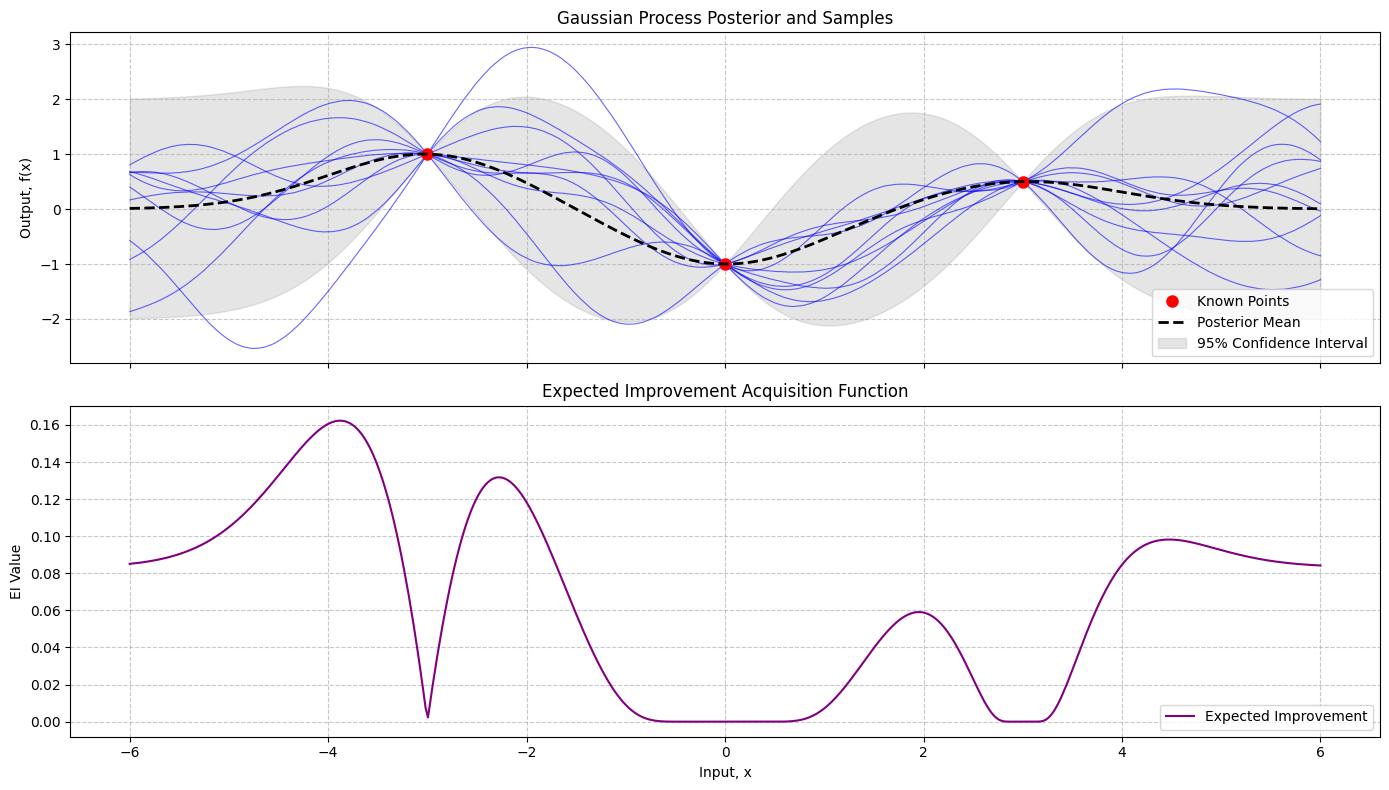

In [7]:
# Define known input (x_observed) and output (y_observed) points
x_observed = np.array([-3., 0., 3.])
y_observed = np.array([1., -1., 0.5])
noise_variance = 1e-8 # A very small noise for observations, assuming negligible measurement error

# Use the same kernel parameters as the first subplot (signal variance = 1, length scale = 1)
signal_variance_prior = 1.0
length_scale_prior = 1.0

# Calculate kernel matrices for the observed data and prediction points
K_obs_obs = squaredExponential(x_observed, x_observed, signal_variance_prior, length_scale_prior)
K_pred_obs = squaredExponential(x, x_observed, signal_variance_prior, length_scale_prior)
K_pred_pred = squaredExponential(x, x, signal_variance_prior, length_scale_prior)

# Add noise variance to the observed kernel matrix for numerical stability
K_obs_obs_noisy = K_obs_obs + noise_variance * np.eye(len(x_observed))

# Calculate the inverse of the noisy observed kernel matrix
K_obs_obs_noisy_inv = np.linalg.inv(K_obs_obs_noisy)

# Calculate the posterior mean
mu_post = K_pred_obs @ K_obs_obs_noisy_inv @ y_observed

# Calculate the posterior covariance
Sigma_post = K_pred_pred - K_pred_obs @ K_obs_obs_noisy_inv @ K_pred_obs.T

# Add jitter for numerical stability to the posterior covariance matrix
jitter = 1e-6
Sigma_post_stable = Sigma_post + jitter * np.eye(len(x))

# Create a multivariate normal distribution for the posterior GP
posterior_gp = tfd.MultivariateNormalTriL(
    loc = mu_post,
    scale_tril = tf.linalg.cholesky(Sigma_post_stable)
)

# Draw 10 samples (functions) from the posterior GP
f_posterior_samples = posterior_gp.sample(10)

# Plotting
fig, (ax_gp, ax_acq) = plt.subplots(2, 1, figsize=(14,8), sharex=True) # Changed to 2 subplots, increased height

# --- GP Plot (Top Subplot) ---
# Plot the sampled functions from the posterior GP
for i in range(f_posterior_samples.shape[0]):
    ax_gp.plot(x, f_posterior_samples[i], alpha=0.6, color='blue', linewidth=0.8)

# Plot the known data points
ax_gp.plot(x_observed, y_observed, 'o', markersize=8, color='red', label='Known Points')

# Plot the posterior mean function
ax_gp.plot(x, mu_post, color='black', linestyle='--', linewidth=2, label='Posterior Mean')

# Plot the error bands (2 standard deviations from the posterior mean)
std_dev_post = np.sqrt(np.diag(Sigma_post))
ax_gp.fill_between(
    x,
    mu_post - 2 * std_dev_post,
    mu_post + 2 * std_dev_post,
    alpha = 0.2,
    color = "grey",
    label = "95% Confidence Interval"
)

ax_gp.set_title("Gaussian Process Posterior and Samples") # New title for GP subplot
ax_gp.set_ylabel("Output, f(x)")
ax_gp.legend(loc='lower right')
ax_gp.grid(True, linestyle='--', alpha=0.7)

# --- Acquisition Function Plot (Bottom Subplot) ---
# Calculate Expected Improvement (EI)
f_best = np.max(y_observed) # Current best observed value

# Avoid division by zero for std_dev_post where it might be extremely small or zero
std_dev_post_safe = np.where(std_dev_post > 1e-10, std_dev_post, 1e-10)

Z = (mu_post - f_best) / std_dev_post_safe

expected_improvement = np.where(
    std_dev_post > 1e-10,
    (mu_post - f_best) * norm.cdf(Z) + std_dev_post * norm.pdf(Z),
    0.0
)

ax_acq.plot(x, expected_improvement, color='purple', label='Expected Improvement')
ax_acq.set_title("Expected Improvement Acquisition Function")
ax_acq.set_xlabel("Input, x")
ax_acq.set_ylabel("EI Value")
ax_acq.grid(True, linestyle='--', alpha=0.7)
ax_acq.legend(loc='lower right') # Adjust legend position for acquisition plot

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig('gp_and_acquisition_function.png', dpi=300) # New filename
plt.show()

# Toy objective function

In [8]:
def true_obj_func(x):
  return ((-1*x*np.sin(x)) + (x/3))/2

$$\frac{\left(-x\sin x\ +\ \frac{x}{3}\right)}{2}$$

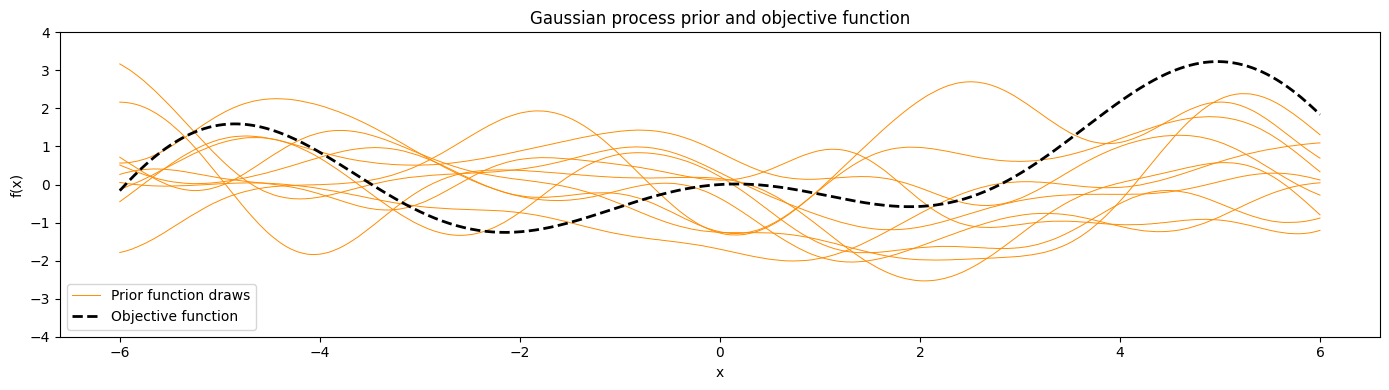

In [9]:
fig, ax = plt.subplots(figsize=(14,4))

for i in range(f1.shape[0]-1):
    ax.plot(x, f1[i], color = "darkorange", lw=0.7)
ax.plot(x, f1[f1.shape[0]-1], label = "Prior function draws", color = "darkorange", lw=0.7)
ax.plot(x, true_obj_func(x), lw=2, color="black", linestyle='--', label="Objective function")

ax.set_ylim(-4, 4)

ax.set_xlabel('x')
ax.set_ylabel("f(x)")
ax.set_title("Gaussian process prior and objective function")
ax.legend()

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig('gp_prior_and_objective_function.png', dpi=300)
plt.show()

# Full Bayes opt loop

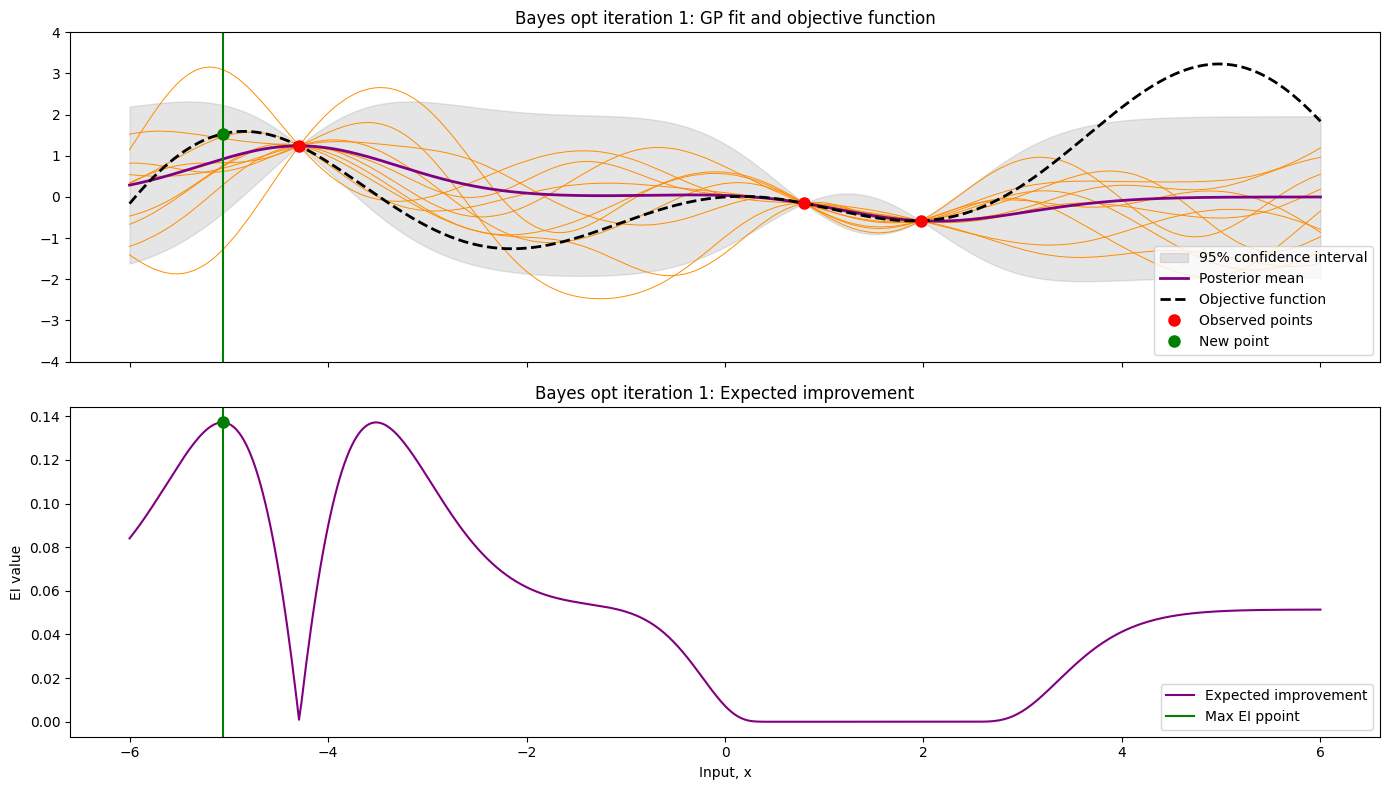

In [10]:
global iteration_count, x_obs, y_obs, next_x_to_observe, next_y_to_observe, bo_iteration_figures

iteration_count = 1

# Defensive initialization block (can be run independently, but sequential execution is recommended)
if 'iteration_count' not in globals():
    iteration_count = 0
    x_obs = np.array([])
    y_obs = np.array([])
    bo_iteration_figures = []

# random generator
rng = np.random.default_rng(seed = 122543)

# If this is the very first iteration, randomly observe 3 initial points
if iteration_count == 1:
    x_obs = rng.uniform(-6, 6, 3)
    y_obs = true_obj_func(x_obs)

# fit the GP to these points
# Use the same kernel parameters as the first subplot (signal variance = 1, length scale = 1)
signal_variance_prior = 1.0
length_scale_prior = 1.0
jitter = 1e-6

# Calculate kernel matrices for the observed data and prediction points
K_obs_obs = squaredExponential(x_obs, x_obs, signal_variance_prior, length_scale_prior)
K_pred_obs = squaredExponential(x, x_obs, signal_variance_prior, length_scale_prior)
K_pred_pred = squaredExponential(x, x, signal_variance_prior, length_scale_prior)

# Add noise variance to the observed kernel matrix for numerical stability
K_obs_obs_noisy = K_obs_obs + jitter * np.eye(len(x_obs))

# Calculate the inverse of the noisy observed kernel matrix
K_obs_obs_noisy_inv = np.linalg.inv(K_obs_obs_noisy)

# Calculate the posterior mean
mu_post = K_pred_obs @ K_obs_obs_noisy_inv @ y_obs

# Calculate the posterior covariance
Sigma_post = K_pred_pred - K_pred_obs @ K_obs_obs_noisy_inv @ K_pred_obs.T

# Add jitter for numerical stability to the posterior covariance matrix
Sigma_post_stable = Sigma_post + jitter * np.eye(len(x))

# Create a multivariate normal distribution for the posterior GP
posterior_gp = tfd.MultivariateNormalTriL(
    loc = mu_post,
    scale_tril = tf.linalg.cholesky(Sigma_post_stable)
)

# Draw 10 samples (functions) from the posterior GP
f_posterior_samples = posterior_gp.sample(10)

# Calculate Expected Improvement (EI)
f_best = np.max(y_obs) # Current best observed value

# Avoid division by zero for std_dev_post where it might be extremely small or zero
std_dev_post = np.sqrt(np.diag(Sigma_post))
std_dev_post_safe = np.where(std_dev_post > 1e-10, std_dev_post, 1e-10)

Z = (mu_post - f_best) / std_dev_post_safe

expected_improvement = np.where(
    std_dev_post > 1e-10,
    (mu_post - f_best) * norm.cdf(Z) + std_dev_post * norm.pdf(Z),
    0.0
)

# Determine the next point to observe
next_x_to_observe_idx = np.argmax(expected_improvement)
next_x_to_observe = x[next_x_to_observe_idx]
next_y_to_observe = true_obj_func(next_x_to_observe)

# Plotting
current_fig = plot_bo_iteration(x, true_obj_func, x_obs, y_obs, mu_post, std_dev_post,
                                f_posterior_samples, expected_improvement,
                                next_x_to_observe, next_y_to_observe, iteration_count)
bo_iteration_figures.append(current_fig)

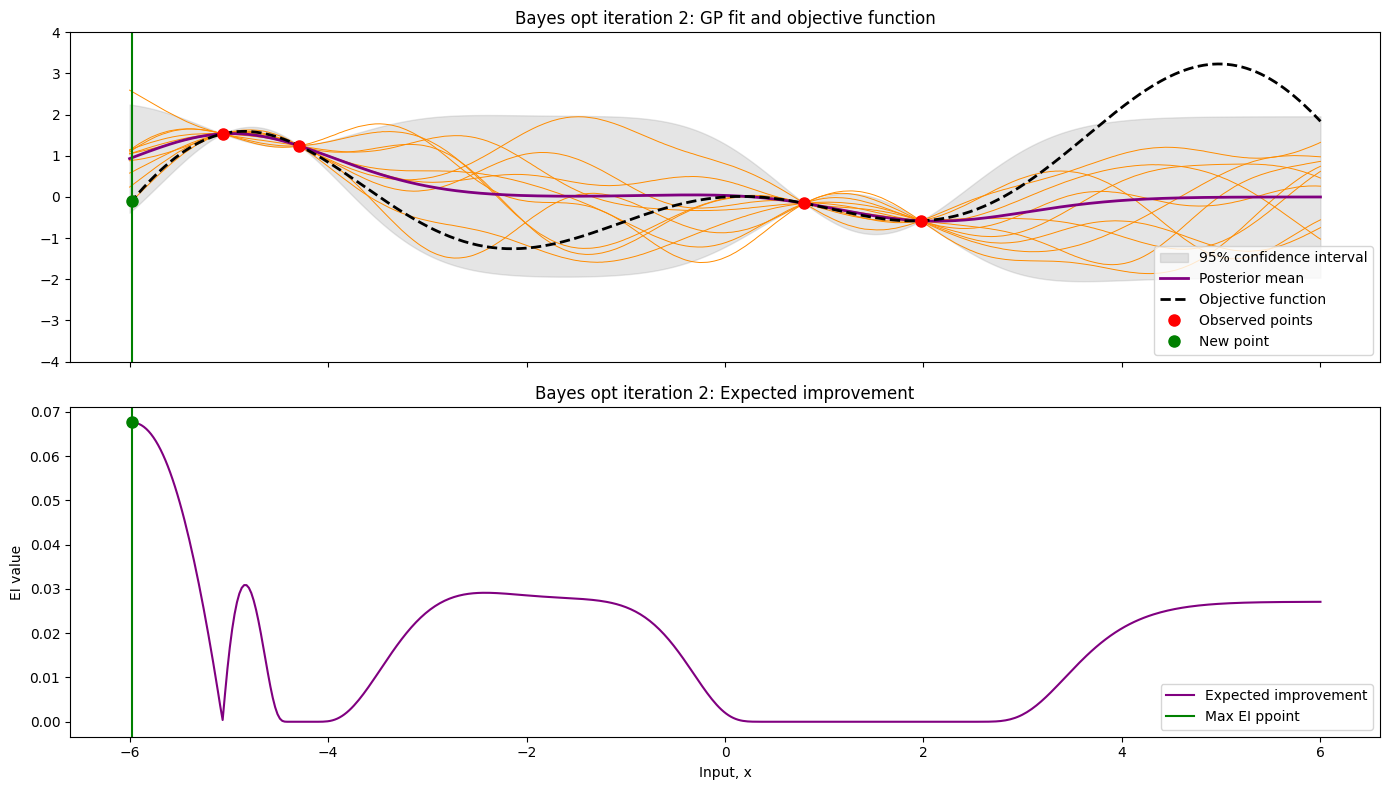

In [11]:
# Increment iteration count for the current iteration (this happens before plotting)
iteration_count += 1

# Append the newly observed point from the previous iteration
x_obs = np.append(x_obs, next_x_to_observe)
y_obs = np.append(y_obs, next_y_to_observe)

# fit the GP to these points
# Use the same kernel parameters as the first subplot (signal variance = 1, length scale = 1)
signal_variance_prior = 1.0
length_scale_prior = 1.0
jitter = 1e-6

# Calculate kernel matrices for the observed data and prediction points
K_obs_obs = squaredExponential(x_obs, x_obs, signal_variance_prior, length_scale_prior)
K_pred_obs = squaredExponential(x, x_obs, signal_variance_prior, length_scale_prior)
K_pred_pred = squaredExponential(x, x, signal_variance_prior, length_scale_prior)

# Add noise variance to the observed kernel matrix for numerical stability
K_obs_obs_noisy = K_obs_obs + jitter * np.eye(len(x_obs))

# Calculate the inverse of the noisy observed kernel matrix
K_obs_obs_noisy_inv = np.linalg.inv(K_obs_obs_noisy)

# Calculate the posterior mean
mu_post = K_pred_obs @ K_obs_obs_noisy_inv @ y_obs

# Calculate the posterior covariance
Sigma_post = K_pred_pred - K_pred_obs @ K_obs_obs_noisy_inv @ K_pred_obs.T

# Add jitter for numerical stability to the posterior covariance matrix
Sigma_post_stable = Sigma_post + jitter * np.eye(len(x))

# Create a multivariate normal distribution for the posterior GP
posterior_gp = tfd.MultivariateNormalTriL(
    loc = mu_post,
    scale_tril = tf.linalg.cholesky(Sigma_post_stable)
)

# Draw 10 samples (functions) from the posterior GP
f_posterior_samples = posterior_gp.sample(10)

# Calculate Expected Improvement (EI)
f_best = np.max(y_obs) # Current best observed value

# Avoid division by zero for std_dev_post where it might be extremely small or zero
std_dev_post = np.sqrt(np.diag(Sigma_post))
std_dev_post_safe = np.where(std_dev_post > 1e-10, std_dev_post, 1e-10)

Z = (mu_post - f_best) / std_dev_post_safe

expected_improvement = np.where(
    std_dev_post > 1e-10,
    (mu_post - f_best) * norm.cdf(Z) + std_dev_post * norm.pdf(Z),
    0.0
)

# Determine the next point to observe
next_x_to_observe_idx = np.argmax(expected_improvement)
next_x_to_observe = x[next_x_to_observe_idx]
next_y_to_observe = true_obj_func(next_x_to_observe)

# Plotting
current_fig = plot_bo_iteration(x, true_obj_func, x_obs, y_obs, mu_post, std_dev_post,
                                f_posterior_samples, expected_improvement,
                                next_x_to_observe, next_y_to_observe, iteration_count)
bo_iteration_figures.append(current_fig)

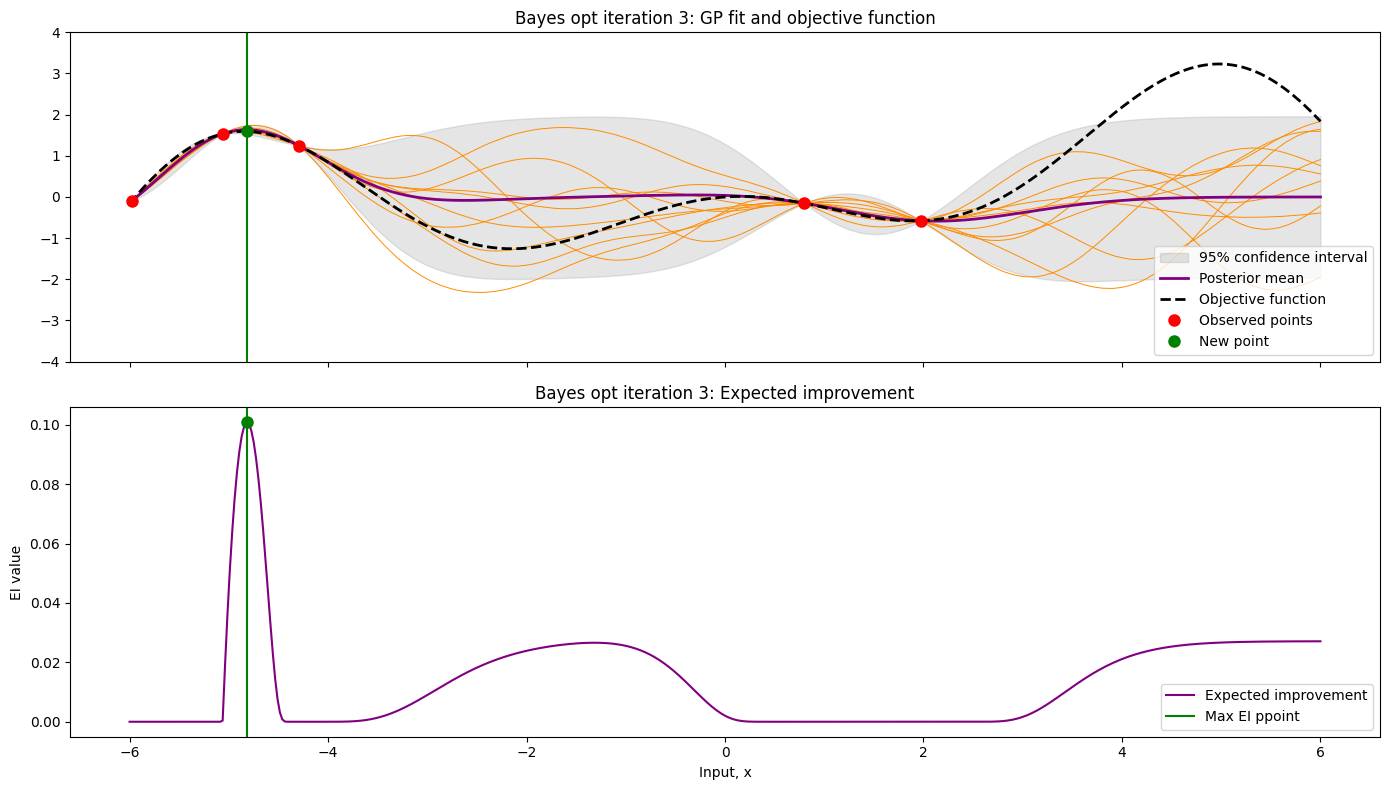

In [12]:
# Increment iteration count for the current iteration (this happens before plotting)
iteration_count += 1

# Append the newly observed point from the previous iteration
x_obs = np.append(x_obs, next_x_to_observe)
y_obs = np.append(y_obs, next_y_to_observe)

# fit the GP to these points
# Use the same kernel parameters as the first subplot (signal variance = 1, length scale = 1)
signal_variance_prior = 1.0
length_scale_prior = 1.0
jitter = 1e-6

# Calculate kernel matrices for the observed data and prediction points
K_obs_obs = squaredExponential(x_obs, x_obs, signal_variance_prior, length_scale_prior)
K_pred_obs = squaredExponential(x, x_obs, signal_variance_prior, length_scale_prior)
K_pred_pred = squaredExponential(x, x, signal_variance_prior, length_scale_prior)

# Add noise variance to the observed kernel matrix for numerical stability
K_obs_obs_noisy = K_obs_obs + jitter * np.eye(len(x_obs))

# Calculate the inverse of the noisy observed kernel matrix
K_obs_obs_noisy_inv = np.linalg.inv(K_obs_obs_noisy)

# Calculate the posterior mean
mu_post = K_pred_obs @ K_obs_obs_noisy_inv @ y_obs

# Calculate the posterior covariance
Sigma_post = K_pred_pred - K_pred_obs @ K_obs_obs_noisy_inv @ K_pred_obs.T

# Add jitter for numerical stability to the posterior covariance matrix
Sigma_post_stable = Sigma_post + jitter * np.eye(len(x))

# Create a multivariate normal distribution for the posterior GP
posterior_gp = tfd.MultivariateNormalTriL(
    loc = mu_post,
    scale_tril = tf.linalg.cholesky(Sigma_post_stable)
)

# Draw 10 samples (functions) from the posterior GP
f_posterior_samples = posterior_gp.sample(10)

# Calculate Expected Improvement (EI)
f_best = np.max(y_obs) # Current best observed value

# Avoid division by zero for std_dev_post where it might be extremely small or zero
std_dev_post = np.sqrt(np.diag(Sigma_post))
std_dev_post_safe = np.where(std_dev_post > 1e-10, std_dev_post, 1e-10)

Z = (mu_post - f_best) / std_dev_post_safe

expected_improvement = np.where(
    std_dev_post > 1e-10,
    (mu_post - f_best) * norm.cdf(Z) + std_dev_post * norm.pdf(Z),
    0.0
)

# Determine the next point to observe
next_x_to_observe_idx = np.argmax(expected_improvement)
next_x_to_observe = x[next_x_to_observe_idx]
next_y_to_observe = true_obj_func(next_x_to_observe)

# Plotting
current_fig = plot_bo_iteration(x, true_obj_func, x_obs, y_obs, mu_post, std_dev_post,
                                f_posterior_samples, expected_improvement,
                                next_x_to_observe, next_y_to_observe, iteration_count)
bo_iteration_figures.append(current_fig)

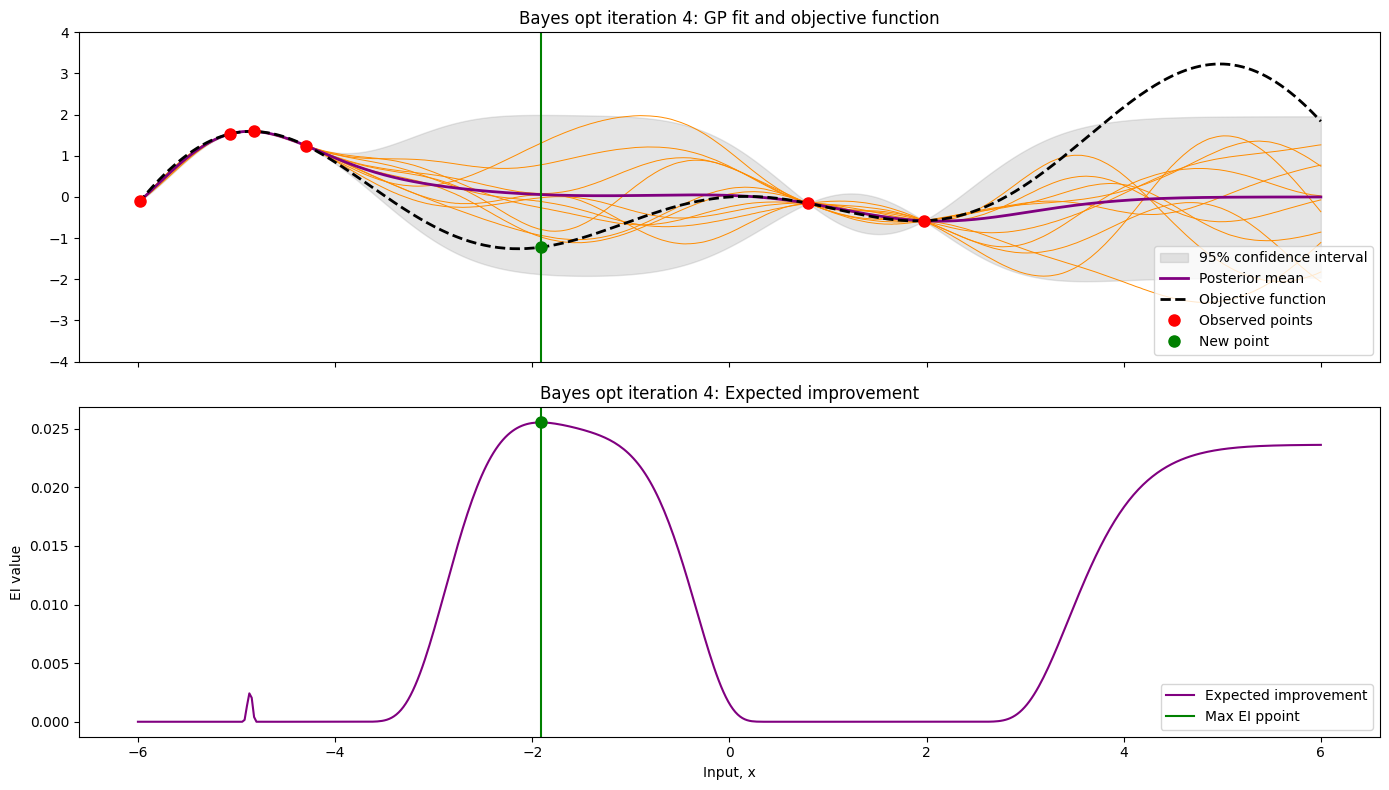

In [13]:
# Increment iteration count for the current iteration (this happens before plotting)
iteration_count += 1

# Append the newly observed point from the previous iteration
x_obs = np.append(x_obs, next_x_to_observe)
y_obs = np.append(y_obs, next_y_to_observe)

# fit the GP to these points
# Use the same kernel parameters as the first subplot (signal variance = 1, length scale = 1)
signal_variance_prior = 1.0
length_scale_prior = 1.0
jitter = 1e-6

# Calculate kernel matrices for the observed data and prediction points
K_obs_obs = squaredExponential(x_obs, x_obs, signal_variance_prior, length_scale_prior)
K_pred_obs = squaredExponential(x, x_obs, signal_variance_prior, length_scale_prior)
K_pred_pred = squaredExponential(x, x, signal_variance_prior, length_scale_prior)

# Add noise variance to the observed kernel matrix for numerical stability
K_obs_obs_noisy = K_obs_obs + jitter * np.eye(len(x_obs))

# Calculate the inverse of the noisy observed kernel matrix
K_obs_obs_noisy_inv = np.linalg.inv(K_obs_obs_noisy)

# Calculate the posterior mean
mu_post = K_pred_obs @ K_obs_obs_noisy_inv @ y_obs

# Calculate the posterior covariance
Sigma_post = K_pred_pred - K_pred_obs @ K_obs_obs_noisy_inv @ K_pred_obs.T

# Add jitter for numerical stability to the posterior covariance matrix
Sigma_post_stable = Sigma_post + jitter * np.eye(len(x))

# Create a multivariate normal distribution for the posterior GP
posterior_gp = tfd.MultivariateNormalTriL(
    loc = mu_post,
    scale_tril = tf.linalg.cholesky(Sigma_post_stable)
)

# Draw 10 samples (functions) from the posterior GP
f_posterior_samples = posterior_gp.sample(10)

# Calculate Expected Improvement (EI)
f_best = np.max(y_obs) # Current best observed value

# Avoid division by zero for std_dev_post where it might be extremely small or zero
std_dev_post = np.sqrt(np.diag(Sigma_post))
std_dev_post_safe = np.where(std_dev_post > 1e-10, std_dev_post, 1e-10)

Z = (mu_post - f_best) / std_dev_post_safe

expected_improvement = np.where(
    std_dev_post > 1e-10,
    (mu_post - f_best) * norm.cdf(Z) + std_dev_post * norm.pdf(Z),
    0.0
)

# Determine the next point to observe
next_x_to_observe_idx = np.argmax(expected_improvement)
next_x_to_observe = x[next_x_to_observe_idx]
next_y_to_observe = true_obj_func(next_x_to_observe)

# Plotting
current_fig = plot_bo_iteration(x, true_obj_func, x_obs, y_obs, mu_post, std_dev_post,
                                f_posterior_samples, expected_improvement,
                                next_x_to_observe, next_y_to_observe, iteration_count)
bo_iteration_figures.append(current_fig)

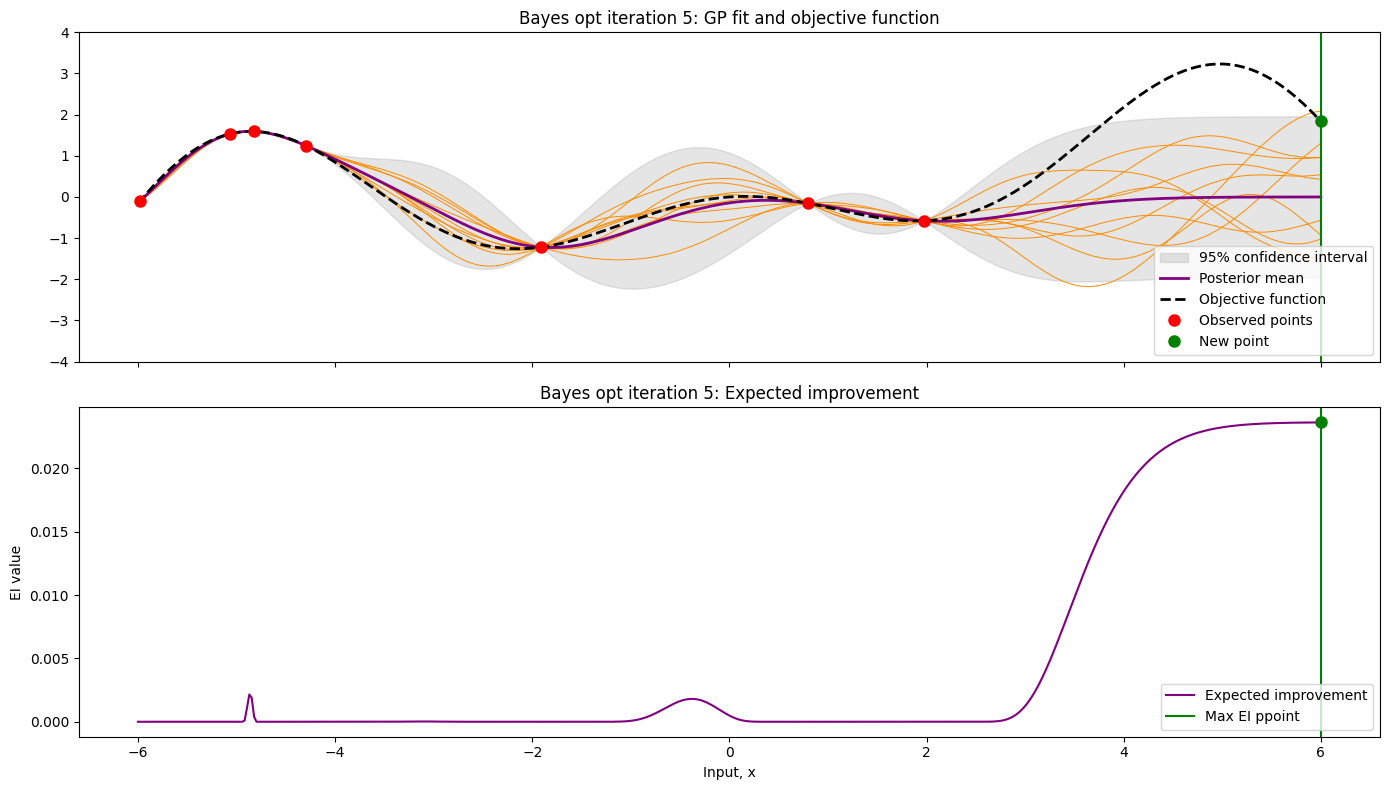

In [14]:
# Increment iteration count for the current iteration (this happens before plotting)
iteration_count += 1

# Append the newly observed point from the previous iteration
x_obs = np.append(x_obs, next_x_to_observe)
y_obs = np.append(y_obs, next_y_to_observe)

# fit the GP to these points
# Use the same kernel parameters as the first subplot (signal variance = 1, length scale = 1)
signal_variance_prior = 1.0
length_scale_prior = 1.0
jitter = 1e-6

# Calculate kernel matrices for the observed data and prediction points
K_obs_obs = squaredExponential(x_obs, x_obs, signal_variance_prior, length_scale_prior)
K_pred_obs = squaredExponential(x, x_obs, signal_variance_prior, length_scale_prior)
K_pred_pred = squaredExponential(x, x, signal_variance_prior, length_scale_prior)

# Add noise variance to the observed kernel matrix for numerical stability
K_obs_obs_noisy = K_obs_obs + jitter * np.eye(len(x_obs))

# Calculate the inverse of the noisy observed kernel matrix
K_obs_obs_noisy_inv = np.linalg.inv(K_obs_obs_noisy)

# Calculate the posterior mean
mu_post = K_pred_obs @ K_obs_obs_noisy_inv @ y_obs

# Calculate the posterior covariance
Sigma_post = K_pred_pred - K_pred_obs @ K_obs_obs_noisy_inv @ K_pred_obs.T

# Add jitter for numerical stability to the posterior covariance matrix
Sigma_post_stable = Sigma_post + jitter * np.eye(len(x))

# Create a multivariate normal distribution for the posterior GP
posterior_gp = tfd.MultivariateNormalTriL(
    loc = mu_post,
    scale_tril = tf.linalg.cholesky(Sigma_post_stable)
)

# Draw 10 samples (functions) from the posterior GP
f_posterior_samples = posterior_gp.sample(10)

# Calculate Expected Improvement (EI)
f_best = np.max(y_obs) # Current best observed value

# Avoid division by zero for std_dev_post where it might be extremely small or zero
std_dev_post = np.sqrt(np.diag(Sigma_post))
std_dev_post_safe = np.where(std_dev_post > 1e-10, std_dev_post, 1e-10)

Z = (mu_post - f_best) / std_dev_post_safe

expected_improvement = np.where(
    std_dev_post > 1e-10,
    (mu_post - f_best) * norm.cdf(Z) + std_dev_post * norm.pdf(Z),
    0.0
)

# Determine the next point to observe
next_x_to_observe_idx = np.argmax(expected_improvement)
next_x_to_observe = x[next_x_to_observe_idx]
next_y_to_observe = true_obj_func(next_x_to_observe)

# Plotting
current_fig = plot_bo_iteration(x, true_obj_func, x_obs, y_obs, mu_post, std_dev_post,
                                f_posterior_samples, expected_improvement,
                                next_x_to_observe, next_y_to_observe, iteration_count)
bo_iteration_figures.append(current_fig)

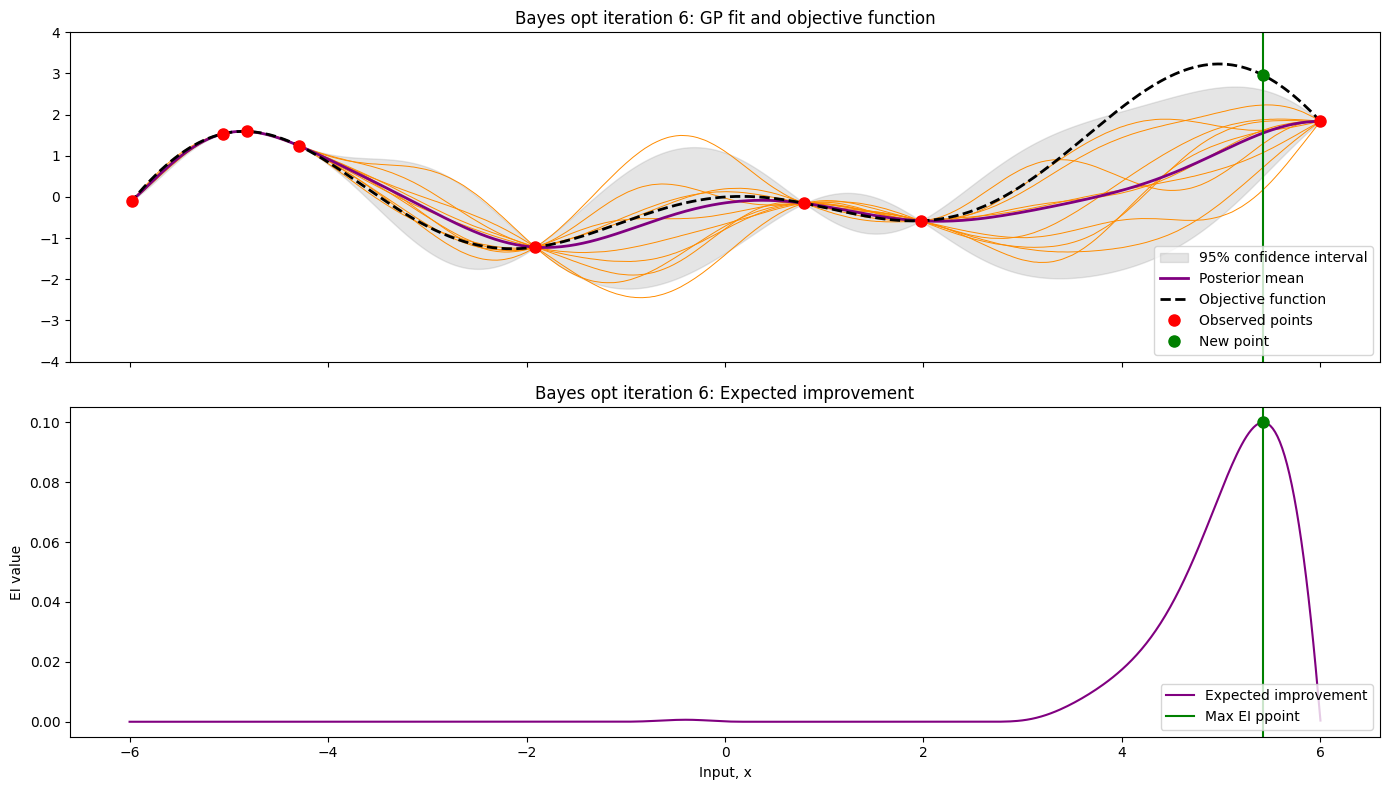

In [15]:
# Increment iteration count for the current iteration (this happens before plotting)
iteration_count += 1

# Append the newly observed point from the previous iteration
x_obs = np.append(x_obs, next_x_to_observe)
y_obs = np.append(y_obs, next_y_to_observe)

# fit the GP to these points
# Use the same kernel parameters as the first subplot (signal variance = 1, length scale = 1)
signal_variance_prior = 1.0
length_scale_prior = 1.0
jitter = 1e-6

# Calculate kernel matrices for the observed data and prediction points
K_obs_obs = squaredExponential(x_obs, x_obs, signal_variance_prior, length_scale_prior)
K_pred_obs = squaredExponential(x, x_obs, signal_variance_prior, length_scale_prior)
K_pred_pred = squaredExponential(x, x, signal_variance_prior, length_scale_prior)

# Add noise variance to the observed kernel matrix for numerical stability
K_obs_obs_noisy = K_obs_obs + jitter * np.eye(len(x_obs))

# Calculate the inverse of the noisy observed kernel matrix
K_obs_obs_noisy_inv = np.linalg.inv(K_obs_obs_noisy)

# Calculate the posterior mean
mu_post = K_pred_obs @ K_obs_obs_noisy_inv @ y_obs

# Calculate the posterior covariance
Sigma_post = K_pred_pred - K_pred_obs @ K_obs_obs_noisy_inv @ K_pred_obs.T

# Add jitter for numerical stability to the posterior covariance matrix
Sigma_post_stable = Sigma_post + jitter * np.eye(len(x))

# Create a multivariate normal distribution for the posterior GP
posterior_gp = tfd.MultivariateNormalTriL(
    loc = mu_post,
    scale_tril = tf.linalg.cholesky(Sigma_post_stable)
)

# Draw 10 samples (functions) from the posterior GP
f_posterior_samples = posterior_gp.sample(10)

# Calculate Expected Improvement (EI)
f_best = np.max(y_obs) # Current best observed value

# Avoid division by zero for std_dev_post where it might be extremely small or zero
std_dev_post = np.sqrt(np.diag(Sigma_post))
std_dev_post_safe = np.where(std_dev_post > 1e-10, std_dev_post, 1e-10)

Z = (mu_post - f_best) / std_dev_post_safe

expected_improvement = np.where(
    std_dev_post > 1e-10,
    (mu_post - f_best) * norm.cdf(Z) + std_dev_post * norm.pdf(Z),
    0.0
)

# Determine the next point to observe
next_x_to_observe_idx = np.argmax(expected_improvement)
next_x_to_observe = x[next_x_to_observe_idx]
next_y_to_observe = true_obj_func(next_x_to_observe)

# Plotting
current_fig = plot_bo_iteration(x, true_obj_func, x_obs, y_obs, mu_post, std_dev_post,
                                f_posterior_samples, expected_improvement,
                                next_x_to_observe, next_y_to_observe, iteration_count)
bo_iteration_figures.append(current_fig)

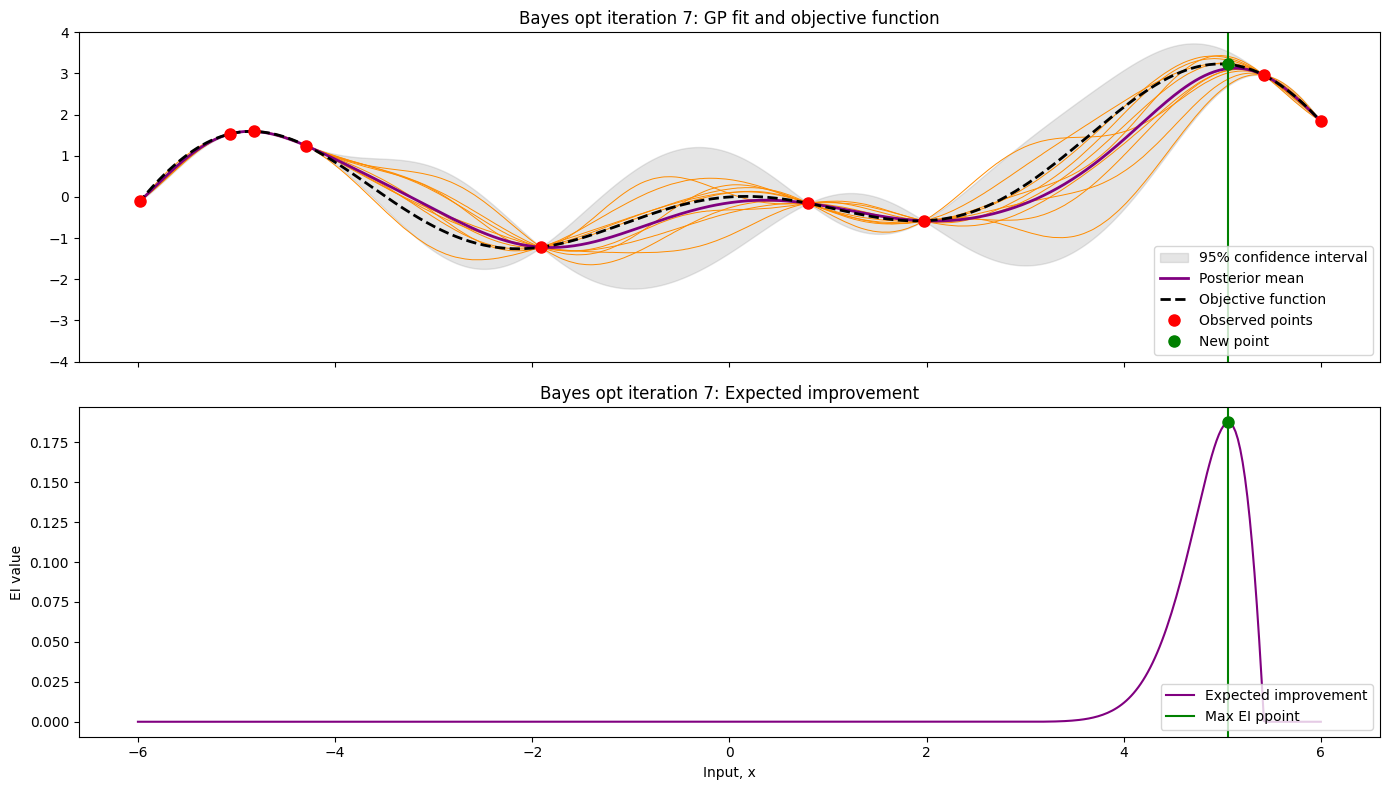

In [16]:
# Increment iteration count for the current iteration (this happens before plotting)
iteration_count += 1

# Append the newly observed point from the previous iteration
x_obs = np.append(x_obs, next_x_to_observe)
y_obs = np.append(y_obs, next_y_to_observe)

# fit the GP to these points
# Use the same kernel parameters as the first subplot (signal variance = 1, length scale = 1)
signal_variance_prior = 1.0
length_scale_prior = 1.0
jitter = 1e-6

# Calculate kernel matrices for the observed data and prediction points
K_obs_obs = squaredExponential(x_obs, x_obs, signal_variance_prior, length_scale_prior)
K_pred_obs = squaredExponential(x, x_obs, signal_variance_prior, length_scale_prior)
K_pred_pred = squaredExponential(x, x, signal_variance_prior, length_scale_prior)

# Add noise variance to the observed kernel matrix for numerical stability
K_obs_obs_noisy = K_obs_obs + jitter * np.eye(len(x_obs))

# Calculate the inverse of the noisy observed kernel matrix
K_obs_obs_noisy_inv = np.linalg.inv(K_obs_obs_noisy)

# Calculate the posterior mean
mu_post = K_pred_obs @ K_obs_obs_noisy_inv @ y_obs

# Calculate the posterior covariance
Sigma_post = K_pred_pred - K_pred_obs @ K_obs_obs_noisy_inv @ K_pred_obs.T

# Add jitter for numerical stability to the posterior covariance matrix
Sigma_post_stable = Sigma_post + jitter * np.eye(len(x))

# Create a multivariate normal distribution for the posterior GP
posterior_gp = tfd.MultivariateNormalTriL(
    loc = mu_post,
    scale_tril = tf.linalg.cholesky(Sigma_post_stable)
)

# Draw 10 samples (functions) from the posterior GP
f_posterior_samples = posterior_gp.sample(10)

# Calculate Expected Improvement (EI)
f_best = np.max(y_obs) # Current best observed value

# Avoid division by zero for std_dev_post where it might be extremely small or zero
std_dev_post = np.sqrt(np.diag(Sigma_post))
std_dev_post_safe = np.where(std_dev_post > 1e-10, std_dev_post, 1e-10)

Z = (mu_post - f_best) / std_dev_post_safe

expected_improvement = np.where(
    std_dev_post > 1e-10,
    (mu_post - f_best) * norm.cdf(Z) + std_dev_post * norm.pdf(Z),
    0.0
)

# Determine the next point to observe
next_x_to_observe_idx = np.argmax(expected_improvement)
next_x_to_observe = x[next_x_to_observe_idx]
next_y_to_observe = true_obj_func(next_x_to_observe)

# Plotting
current_fig = plot_bo_iteration(x, true_obj_func, x_obs, y_obs, mu_post, std_dev_post,
                                f_posterior_samples, expected_improvement,
                                next_x_to_observe, next_y_to_observe, iteration_count)
bo_iteration_figures.append(current_fig)

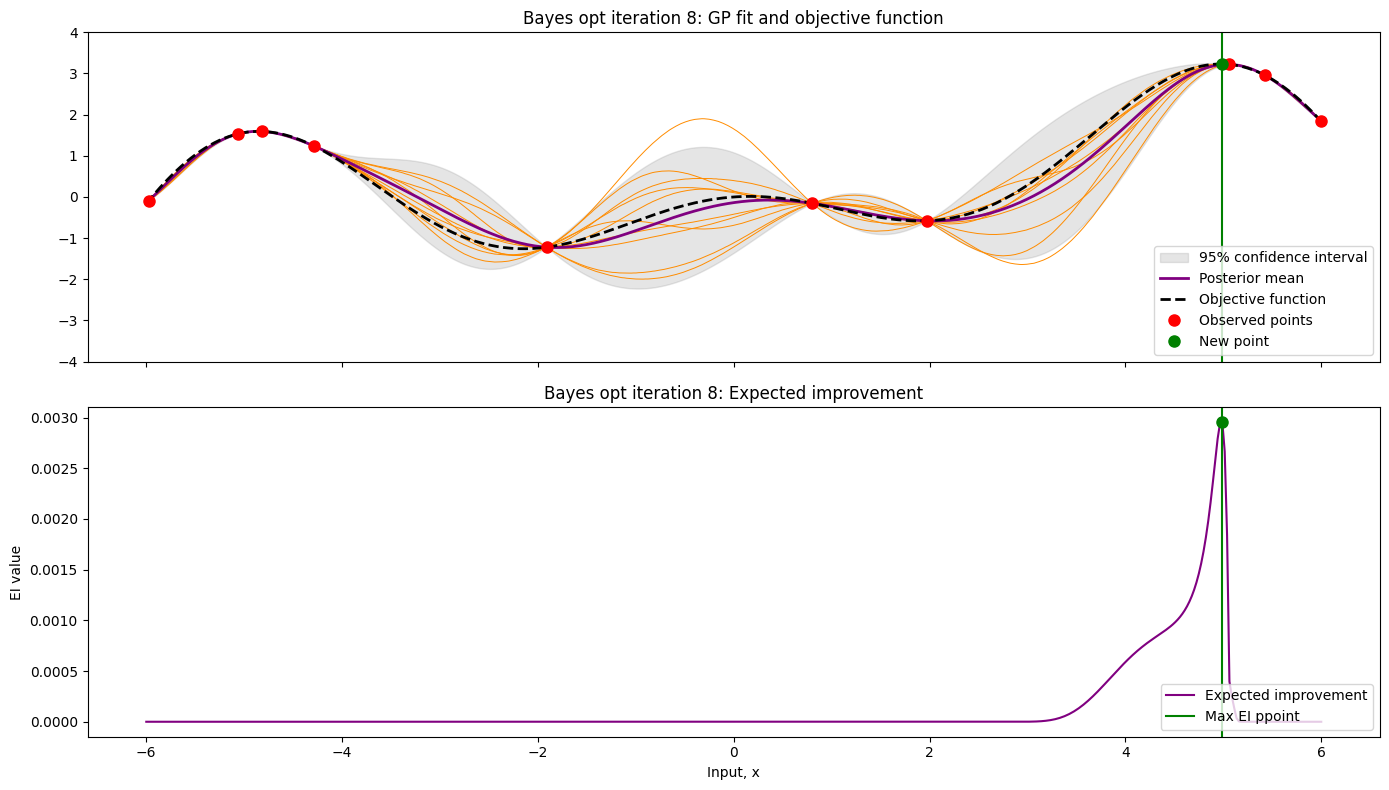

In [17]:
# Increment iteration count for the current iteration (this happens before plotting)
iteration_count += 1

# Append the newly observed point from the previous iteration
x_obs = np.append(x_obs, next_x_to_observe)
y_obs = np.append(y_obs, next_y_to_observe)

# fit the GP to these points
# Use the same kernel parameters as the first subplot (signal variance = 1, length scale = 1)
signal_variance_prior = 1.0
length_scale_prior = 1.0
jitter = 1e-6

# Calculate kernel matrices for the observed data and prediction points
K_obs_obs = squaredExponential(x_obs, x_obs, signal_variance_prior, length_scale_prior)
K_pred_obs = squaredExponential(x, x_obs, signal_variance_prior, length_scale_prior)
K_pred_pred = squaredExponential(x, x, signal_variance_prior, length_scale_prior)

# Add noise variance to the observed kernel matrix for numerical stability
K_obs_obs_noisy = K_obs_obs + jitter * np.eye(len(x_obs))

# Calculate the inverse of the noisy observed kernel matrix
K_obs_obs_noisy_inv = np.linalg.inv(K_obs_obs_noisy)

# Calculate the posterior mean
mu_post = K_pred_obs @ K_obs_obs_noisy_inv @ y_obs

# Calculate the posterior covariance
Sigma_post = K_pred_pred - K_pred_obs @ K_obs_obs_noisy_inv @ K_pred_obs.T

# Add jitter for numerical stability to the posterior covariance matrix
Sigma_post_stable = Sigma_post + jitter * np.eye(len(x))

# Create a multivariate normal distribution for the posterior GP
posterior_gp = tfd.MultivariateNormalTriL(
    loc = mu_post,
    scale_tril = tf.linalg.cholesky(Sigma_post_stable)
)

# Draw 10 samples (functions) from the posterior GP
f_posterior_samples = posterior_gp.sample(10)

# Calculate Expected Improvement (EI)
f_best = np.max(y_obs) # Current best observed value

# Avoid division by zero for std_dev_post where it might be extremely small or zero
std_dev_post = np.sqrt(np.diag(Sigma_post))
std_dev_post_safe = np.where(std_dev_post > 1e-10, std_dev_post, 1e-10)

Z = (mu_post - f_best) / std_dev_post_safe

expected_improvement = np.where(
    std_dev_post > 1e-10,
    (mu_post - f_best) * norm.cdf(Z) + std_dev_post * norm.pdf(Z),
    0.0
)

# Determine the next point to observe
next_x_to_observe_idx = np.argmax(expected_improvement)
next_x_to_observe = x[next_x_to_observe_idx]
next_y_to_observe = true_obj_func(next_x_to_observe)

# Plotting
current_fig = plot_bo_iteration(x, true_obj_func, x_obs, y_obs, mu_post, std_dev_post,
                                f_posterior_samples, expected_improvement,
                                next_x_to_observe, next_y_to_observe, iteration_count)
bo_iteration_figures.append(current_fig)

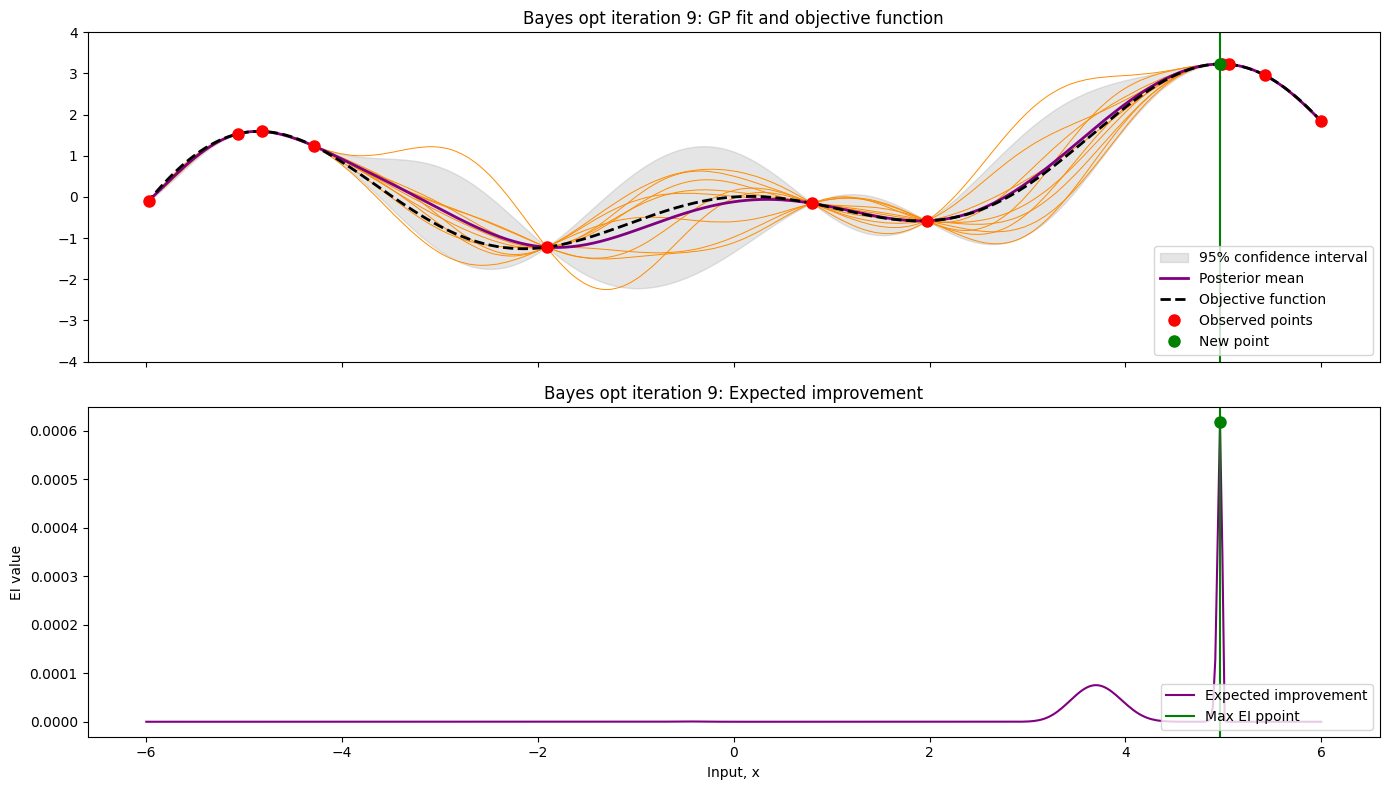

In [18]:
# Increment iteration count for the current iteration (this happens before plotting)
iteration_count += 1

# Append the newly observed point from the previous iteration
x_obs = np.append(x_obs, next_x_to_observe)
y_obs = np.append(y_obs, next_y_to_observe)

# fit the GP to these points
# Use the same kernel parameters as the first subplot (signal variance = 1, length scale = 1)
signal_variance_prior = 1.0
length_scale_prior = 1.0
jitter = 1e-6

# Calculate kernel matrices for the observed data and prediction points
K_obs_obs = squaredExponential(x_obs, x_obs, signal_variance_prior, length_scale_prior)
K_pred_obs = squaredExponential(x, x_obs, signal_variance_prior, length_scale_prior)
K_pred_pred = squaredExponential(x, x, signal_variance_prior, length_scale_prior)

# Add noise variance to the observed kernel matrix for numerical stability
K_obs_obs_noisy = K_obs_obs + jitter * np.eye(len(x_obs))

# Calculate the inverse of the noisy observed kernel matrix
K_obs_obs_noisy_inv = np.linalg.inv(K_obs_obs_noisy)

# Calculate the posterior mean
mu_post = K_pred_obs @ K_obs_obs_noisy_inv @ y_obs

# Calculate the posterior covariance
Sigma_post = K_pred_pred - K_pred_obs @ K_obs_obs_noisy_inv @ K_pred_obs.T

# Add jitter for numerical stability to the posterior covariance matrix
Sigma_post_stable = Sigma_post + jitter * np.eye(len(x))

# Create a multivariate normal distribution for the posterior GP
posterior_gp = tfd.MultivariateNormalTriL(
    loc = mu_post,
    scale_tril = tf.linalg.cholesky(Sigma_post_stable)
)

# Draw 10 samples (functions) from the posterior GP
f_posterior_samples = posterior_gp.sample(10)

# Calculate Expected Improvement (EI)
f_best = np.max(y_obs) # Current best observed value

# Avoid division by zero for std_dev_post where it might be extremely small or zero
std_dev_post = np.sqrt(np.diag(Sigma_post))
std_dev_post_safe = np.where(std_dev_post > 1e-10, std_dev_post, 1e-10)

Z = (mu_post - f_best) / std_dev_post_safe

expected_improvement = np.where(
    std_dev_post > 1e-10,
    (mu_post - f_best) * norm.cdf(Z) + std_dev_post * norm.pdf(Z),
    0.0
)

# Determine the next point to observe
next_x_to_observe_idx = np.argmax(expected_improvement)
next_x_to_observe = x[next_x_to_observe_idx]
next_y_to_observe = true_obj_func(next_x_to_observe)

# Plotting
current_fig = plot_bo_iteration(x, true_obj_func, x_obs, y_obs, mu_post, std_dev_post,
                                f_posterior_samples, expected_improvement,
                                next_x_to_observe, next_y_to_observe, iteration_count)
bo_iteration_figures.append(current_fig)

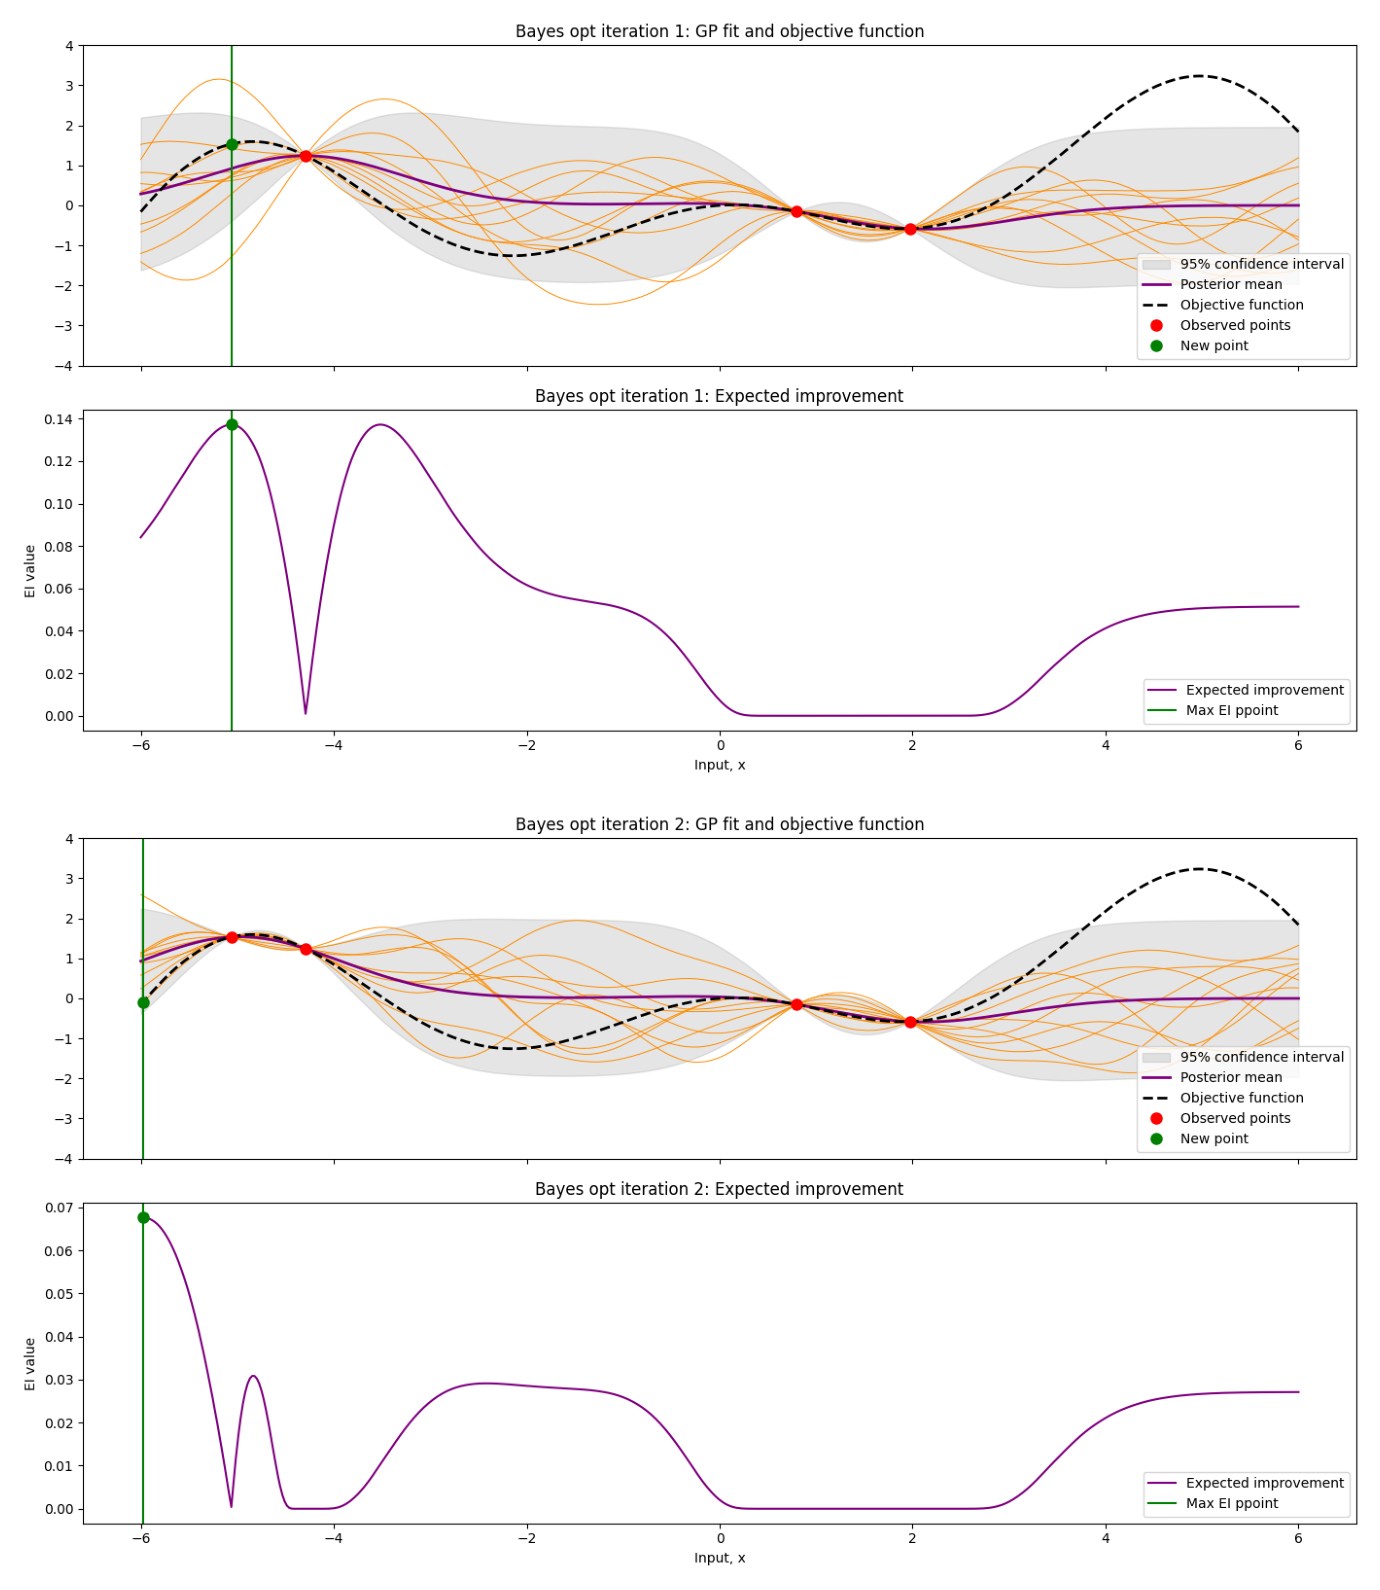

In [21]:
# Assuming bo_iteration_figures contains figures for iterations 1 to 4 at indices 0 to 3
figs_to_stitch_1 = bo_iteration_figures[0:2]

# Use a 4x1 grid for 4 plots
fig1, axes1 = plt.subplots(2, 1, figsize=(14, 8 * len(figs_to_stitch_1)))
axes1 = axes1.flatten()

for i, fig_to_render in enumerate(figs_to_stitch_1):
    if fig_to_render is not None:
        # Render the figure to an in-memory image
        img = render_figure_to_image(fig_to_render)
        axes1[i].imshow(img)
        axes1[i].axis('off')
    else:
        axes1[i].set_title(f"Figure not found for iteration {i+1}", fontsize=12, color='red')
        axes1[i].axis('off')

plt.tight_layout()
plt.savefig('bo12.png', dpi=300, bbox_inches='tight')
plt.show()

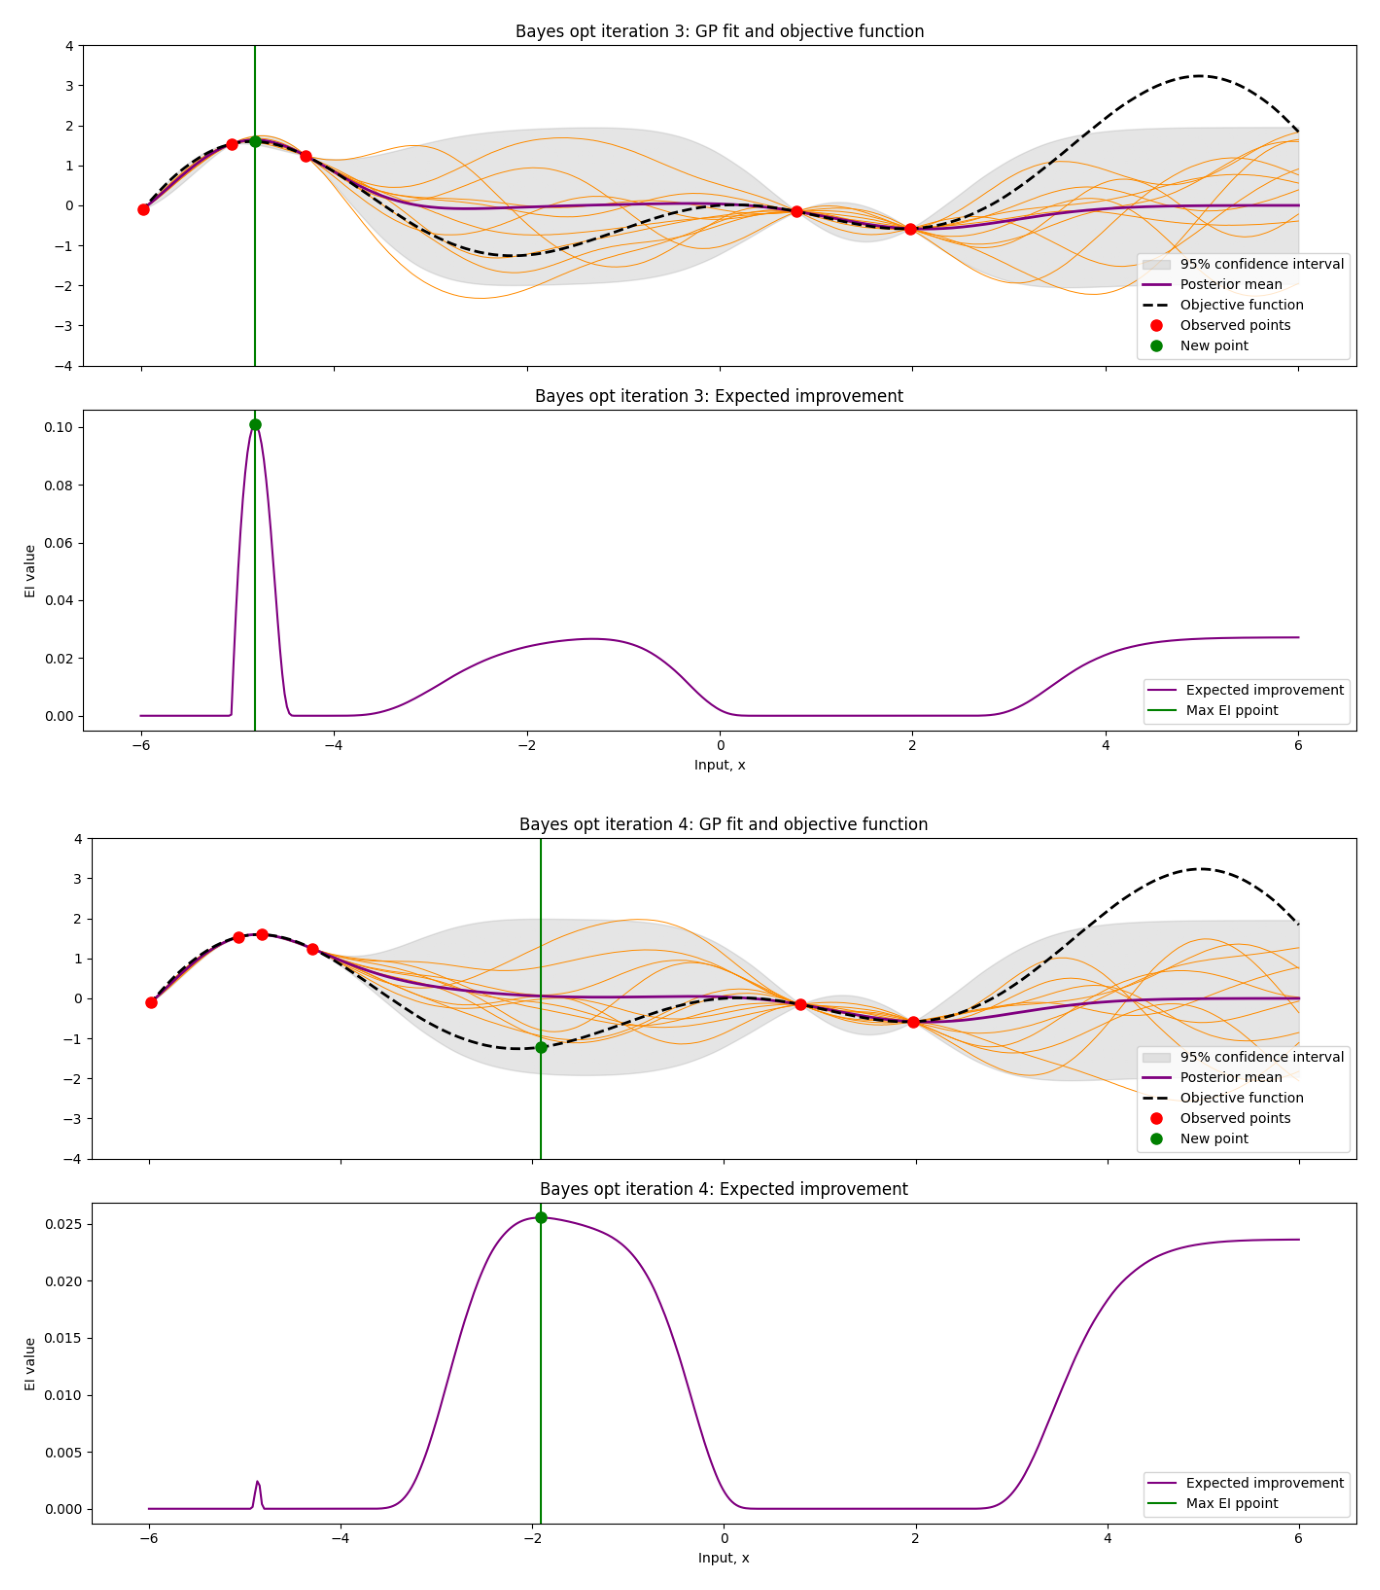

In [22]:
# Assuming bo_iteration_figures contains figures for iterations 1 to 4 at indices 0 to 3
figs_to_stitch_1 = bo_iteration_figures[2:4]

# Use a 4x1 grid for 4 plots
fig1, axes1 = plt.subplots(2, 1, figsize=(14, 8 * len(figs_to_stitch_1)))
axes1 = axes1.flatten()

for i, fig_to_render in enumerate(figs_to_stitch_1):
    if fig_to_render is not None:
        # Render the figure to an in-memory image
        img = render_figure_to_image(fig_to_render)
        axes1[i].imshow(img)
        axes1[i].axis('off')
    else:
        axes1[i].set_title(f"Figure not found for iteration {i+1}", fontsize=12, color='red')
        axes1[i].axis('off')

plt.tight_layout()
plt.savefig('bo34.png', dpi=300, bbox_inches='tight')
plt.show()

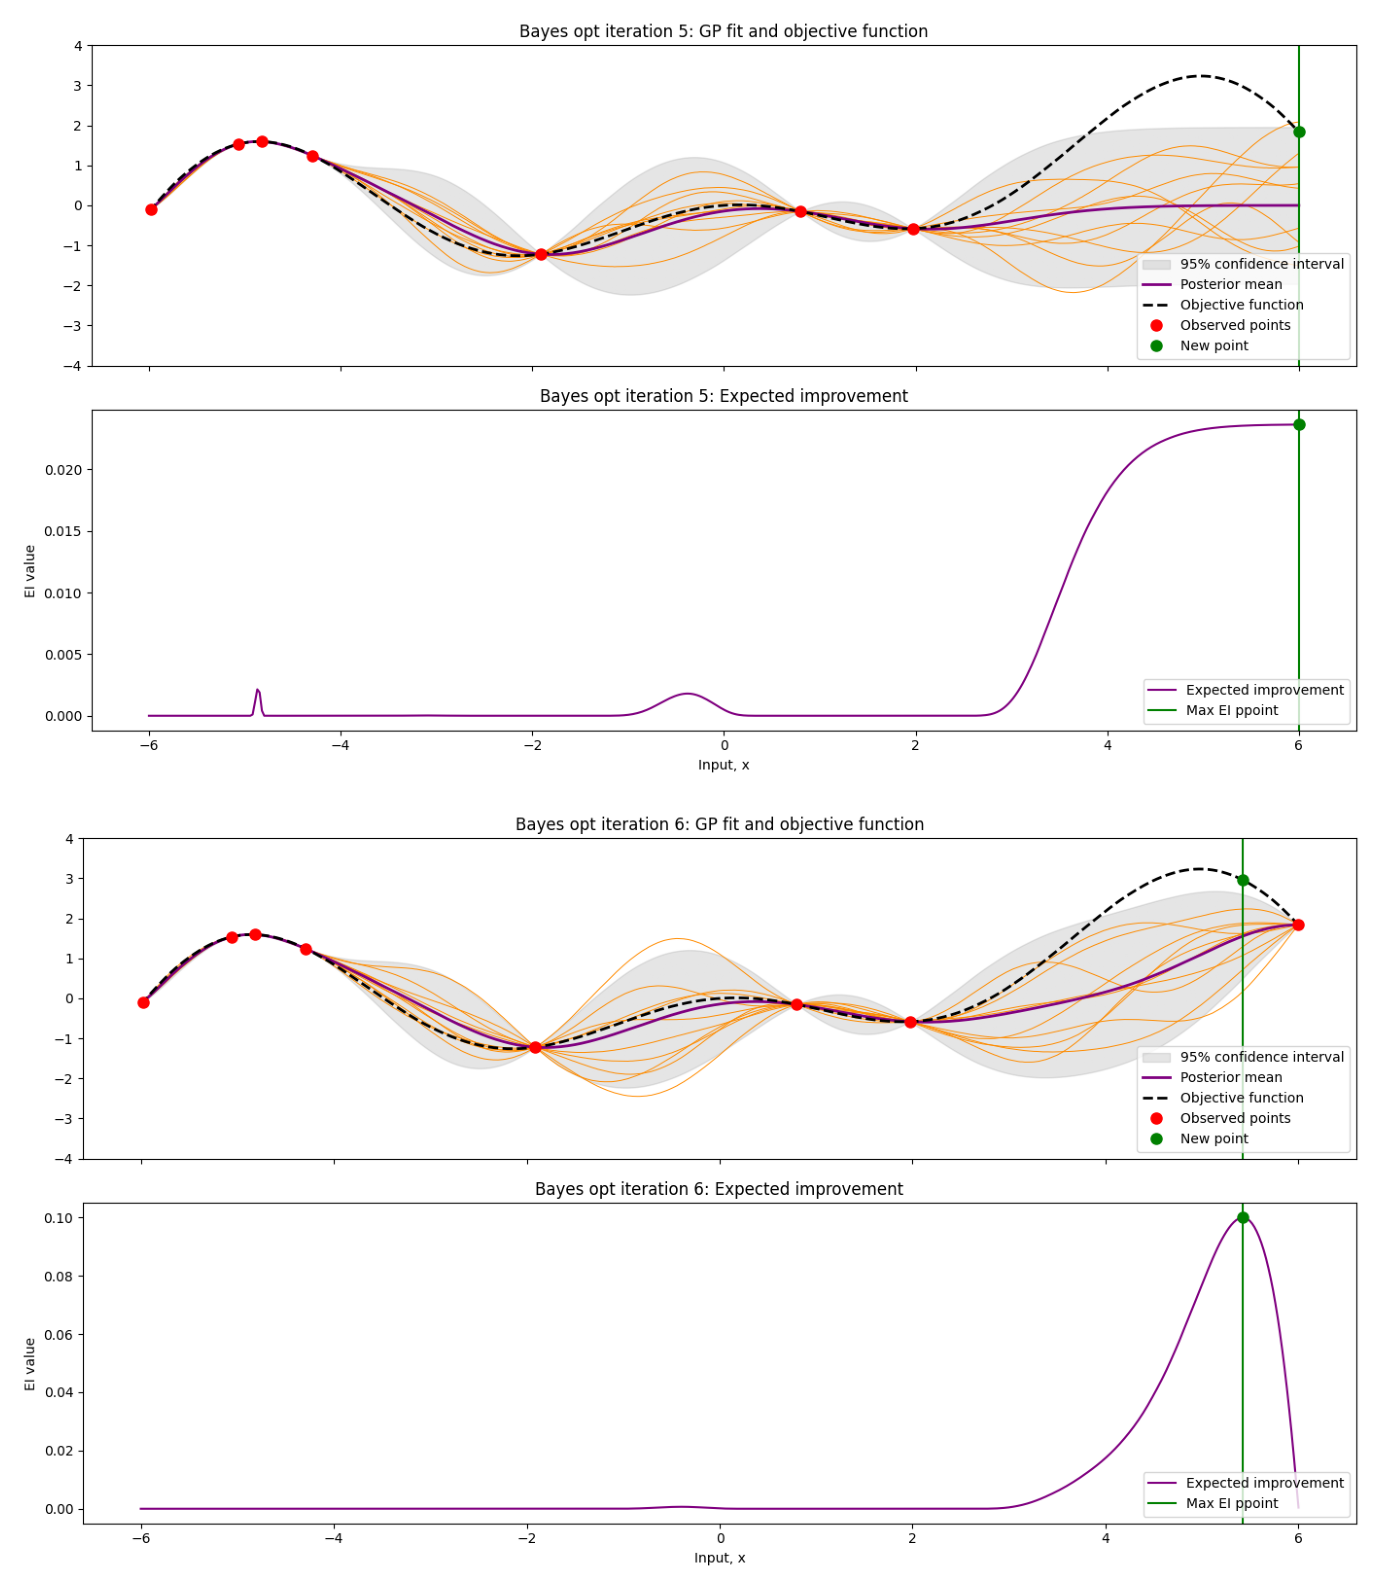

In [23]:
# Assuming bo_iteration_figures contains figures for iterations 1 to 4 at indices 0 to 3
figs_to_stitch_1 = bo_iteration_figures[4:6]

# Use a 4x1 grid for 4 plots
fig1, axes1 = plt.subplots(2, 1, figsize=(14, 8 * len(figs_to_stitch_1)))
axes1 = axes1.flatten()

for i, fig_to_render in enumerate(figs_to_stitch_1):
    if fig_to_render is not None:
        # Render the figure to an in-memory image
        img = render_figure_to_image(fig_to_render)
        axes1[i].imshow(img)
        axes1[i].axis('off')
    else:
        axes1[i].set_title(f"Figure not found for iteration {i+1}", fontsize=12, color='red')
        axes1[i].axis('off')

plt.tight_layout()
# Optional: if you still want to save, you can do so here
plt.savefig('bo56.png', dpi=300, bbox_inches='tight')
plt.show()

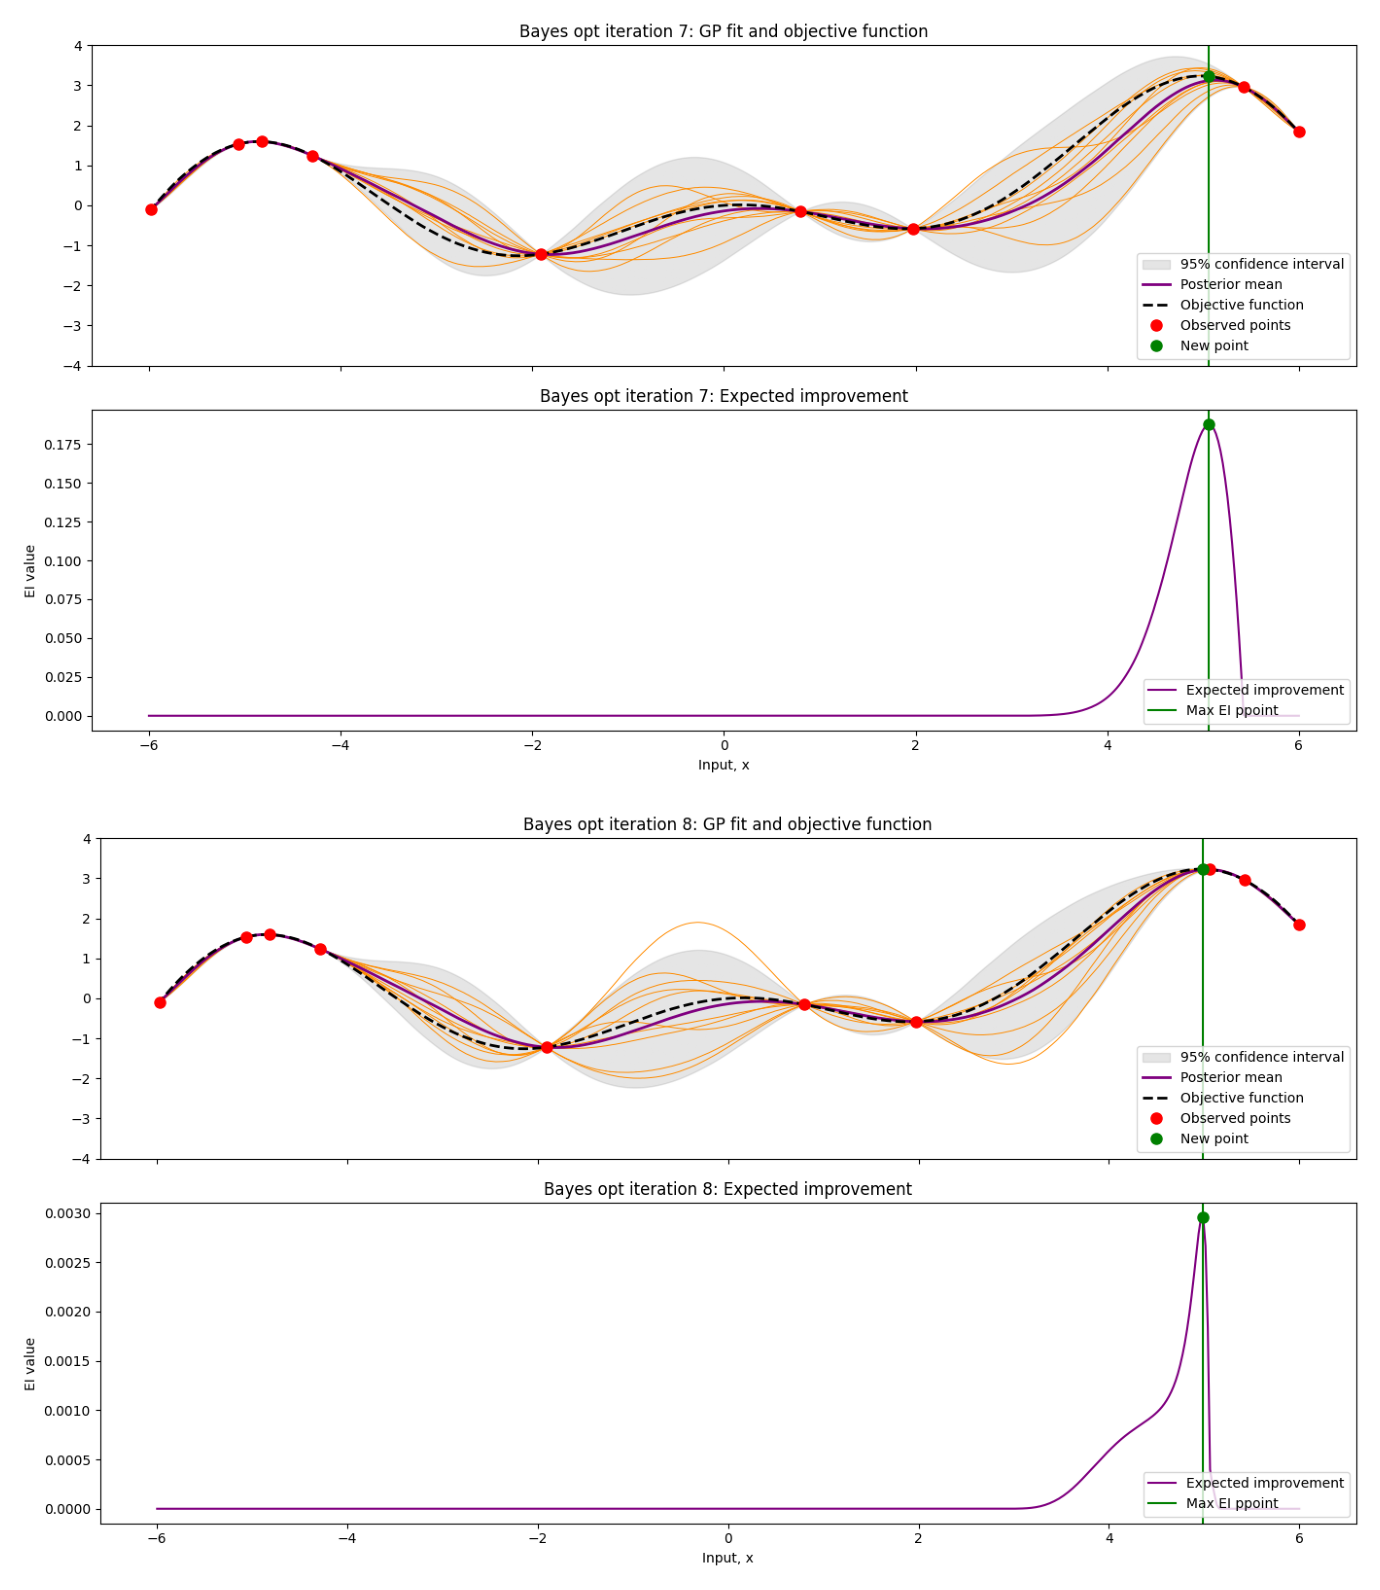

In [24]:
# Assuming bo_iteration_figures contains figures for iterations 1 to 4 at indices 0 to 3
figs_to_stitch_1 = bo_iteration_figures[6:8]

# Use a 4x1 grid for 4 plots
fig1, axes1 = plt.subplots(2, 1, figsize=(14, 8 * len(figs_to_stitch_1)))
axes1 = axes1.flatten()

for i, fig_to_render in enumerate(figs_to_stitch_1):
    if fig_to_render is not None:
        # Render the figure to an in-memory image
        img = render_figure_to_image(fig_to_render)
        axes1[i].imshow(img)
        axes1[i].axis('off')
    else:
        axes1[i].set_title(f"Figure not found for iteration {i+1}", fontsize=12, color='red')
        axes1[i].axis('off')

plt.tight_layout()
# Optional: if you still want to save, you can do so here
plt.savefig('bo78.png', dpi=300, bbox_inches='tight')
plt.show()